# Results Comparison: Antimicrobial Peptide Prediction Models

This notebook provides a comprehensive comparison of all models evaluated on the Veltri and LMPred datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Set figure defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10

## 1. Load Results

In [2]:
# Load results
results = pd.read_csv('results_all_models.csv')

print("=" * 80)
print("ALL MODEL RESULTS")
print("=" * 80)
print(results.to_string(index=False))
print("\n")

ALL MODEL RESULTS
            Model Dataset  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC
Baseline-LR (k=3)  Veltri       0.827949        0.822069     0.837079 0.829506  0.906779
Baseline-LR (k=3)  LMPred       0.749917        0.741479     0.767132 0.754088  0.814845
         ProtBERT  Veltri       0.859551        0.892638     0.817416 0.853372  0.921190
         ProtBERT  LMPred       0.868640        0.849747     0.895542 0.872044  0.930630
            ESM-2  Veltri       0.924157        0.953453     0.891854 0.921626  0.971142
            ESM-2  LMPred       0.847024        0.854521     0.836327 0.845326  0.914773
           ProtT5  Veltri       0.897472        0.984589     0.807584 0.887346  0.954437
           ProtT5  LMPred       0.888926        0.877828     0.903526 0.890492  0.939351




## 2. Summary Statistics

In [3]:
# Summary by dataset
print("=" * 80)
print("VELTRI DATASET RESULTS")
print("=" * 80)
veltri_results = results[results['Dataset'] == 'Veltri'].copy()
veltri_results = veltri_results.sort_values('Test_F1', ascending=False)
print(veltri_results.to_string(index=False))
print("\n")

print("=" * 80)
print("LMPRED DATASET RESULTS")
print("=" * 80)
lmpred_results = results[results['Dataset'] == 'LMPred'].copy()
lmpred_results = lmpred_results.sort_values('Test_F1', ascending=False)
print(lmpred_results.to_string(index=False))
print("\n")

VELTRI DATASET RESULTS
            Model Dataset  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC
            ESM-2  Veltri       0.924157        0.953453     0.891854 0.921626  0.971142
           ProtT5  Veltri       0.897472        0.984589     0.807584 0.887346  0.954437
         ProtBERT  Veltri       0.859551        0.892638     0.817416 0.853372  0.921190
Baseline-LR (k=3)  Veltri       0.827949        0.822069     0.837079 0.829506  0.906779


LMPRED DATASET RESULTS
            Model Dataset  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_AUC
           ProtT5  LMPred       0.888926        0.877828     0.903526 0.890492  0.939351
         ProtBERT  LMPred       0.868640        0.849747     0.895542 0.872044  0.930630
            ESM-2  LMPred       0.847024        0.854521     0.836327 0.845326  0.914773
Baseline-LR (k=3)  LMPred       0.749917        0.741479     0.767132 0.754088  0.814845




In [4]:
# Best model per dataset
print("=" * 80)
print("BEST MODELS BY DATASET")
print("=" * 80)

for dataset in ['Veltri', 'LMPred']:
    dataset_results = results[results['Dataset'] == dataset]
    best_model = dataset_results.loc[dataset_results['Test_F1'].idxmax()]

    print(f"\n{dataset} Dataset:")
    print(f"  Best Model: {best_model['Model']}")
    print(f"  Accuracy:   {best_model['Test_Accuracy']:.4f}")
    print(f"  Precision:  {best_model['Test_Precision']:.4f}")
    print(f"  Recall:     {best_model['Test_Recall']:.4f}")
    print(f"  F1-Score:   {best_model['Test_F1']:.4f}")
    print(f"  AUC:        {best_model['Test_AUC']:.4f}")

print("\n" + "=" * 80)

BEST MODELS BY DATASET

Veltri Dataset:
  Best Model: ESM-2
  Accuracy:   0.9242
  Precision:  0.9535
  Recall:     0.8919
  F1-Score:   0.9216
  AUC:        0.9711

LMPred Dataset:
  Best Model: ProtT5
  Accuracy:   0.8889
  Precision:  0.8778
  Recall:     0.9035
  F1-Score:   0.8905
  AUC:        0.9394



## 3. Performance Comparison: Bar Charts

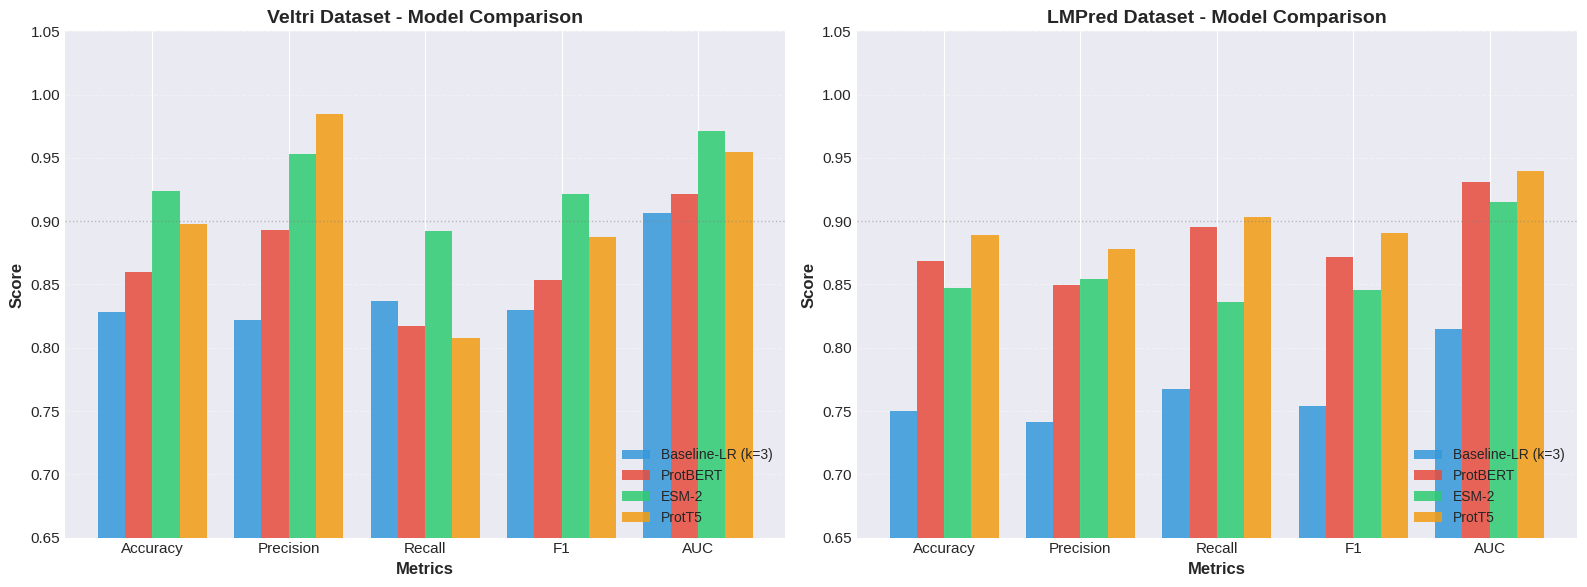

✓ Saved: model_comparison_bar.png


In [5]:
# Comparison bar chart for both datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_AUC']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']  # Blue, Red, Green, Orange

for idx, dataset in enumerate(['Veltri', 'LMPred']):
    data = results[results['Dataset'] == dataset]

    x = np.arange(len(metrics))
    width = 0.2

    models = data['Model'].unique()

    for i, model in enumerate(models):
        model_data = data[data['Model'] == model]
        scores = model_data[metrics].values[0]
        offset = (i - len(models)/2 + 0.5) * width
        axes[idx].bar(x + offset, scores, width, label=model, alpha=0.85, color=colors[i])

    axes[idx].set_xlabel('Metrics', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{dataset} Dataset - Model Comparison', fontsize=14, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(metric_labels)
    axes[idx].legend(loc='lower right', framealpha=0.9)
    axes[idx].set_ylim([0.65, 1.05])
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].axhline(y=0.9, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: model_comparison_bar.png")

## 4. Heatmap: Performance Across Models and Datasets

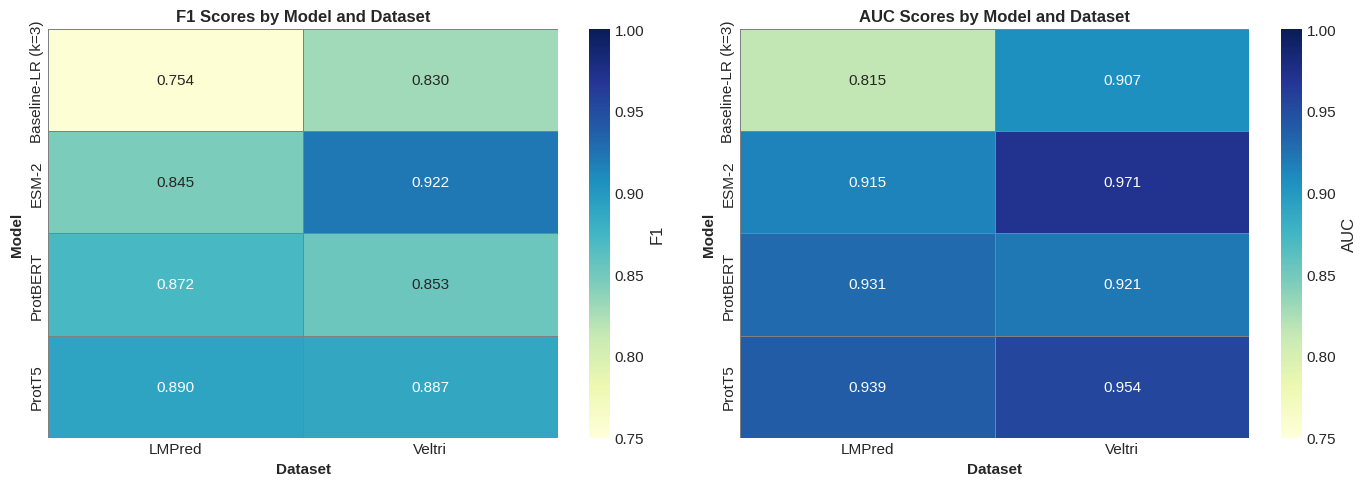

✓ Saved: performance_heatmap.png


In [6]:
# Create pivot table for heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, metric in enumerate(['Test_F1', 'Test_AUC']):
    pivot = results.pivot(index='Model', columns='Dataset', values=metric)

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
                cbar_kws={'label': metric.replace('Test_', '')},
                linewidths=0.5, linecolor='gray',
                vmin=0.75, vmax=1.0,
                ax=axes[idx])

    axes[idx].set_title(f'{metric.replace("Test_", "")} Scores by Model and Dataset',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Dataset', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Model', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: performance_heatmap.png")

## 5. Radar Chart: Multi-Metric Comparison

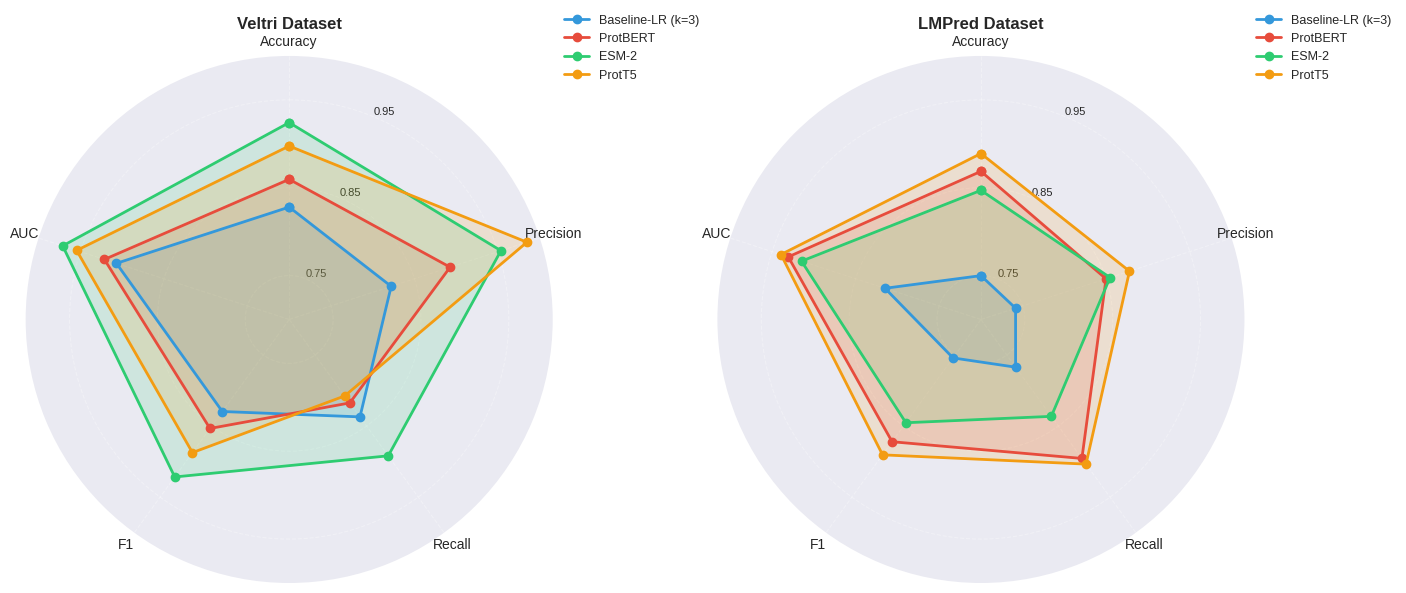

✓ Saved: radar_comparison.png


In [7]:
from math import pi

def create_radar_chart(dataset_name, ax):
    """
    Create radar chart for all models on a specific dataset
    """
    data = results[results['Dataset'] == dataset_name]

    # Metrics to plot
    categories = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
    metric_cols = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_AUC']

    # Number of variables
    N = len(categories)

    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialize plot
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Draw one axis per variable and add labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)

    # Set y-axis limits
    ax.set_ylim(0.7, 1.0)
    ax.set_yticks([0.75, 0.85, 0.95])
    ax.set_yticklabels(['0.75', '0.85', '0.95'], size=8)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Plot each model
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    for idx, (_, row) in enumerate(data.iterrows()):
        values = row[metric_cols].values.tolist()
        values += values[:1]

        ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
        ax.fill(angles, values, alpha=0.15, color=colors[idx])

    ax.set_title(f'{dataset_name} Dataset', size=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

# Create radar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection='polar'))

create_radar_chart('Veltri', axes[0])
create_radar_chart('LMPred', axes[1])

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: radar_comparison.png")

## 6. Improvement Over Baseline

In [8]:
# Calculate improvement over baseline
print("=" * 80)
print("IMPROVEMENT OVER BASELINE")
print("=" * 80)

for dataset in ['Veltri', 'LMPred']:
    data = results[results['Dataset'] == dataset]
    baseline = data[data['Model'] == 'Baseline-LR (k=3)'].iloc[0]

    print(f"\n{dataset} Dataset:")
    print(f"{'Model':<20} {'Acc Δ':<10} {'F1 Δ':<10} {'AUC Δ':<10}")
    print("-" * 50)

    for _, row in data.iterrows():
        if row['Model'] == 'Baseline-LR (k=3)':
            continue

        acc_imp = (row['Test_Accuracy'] - baseline['Test_Accuracy']) * 100
        f1_imp = (row['Test_F1'] - baseline['Test_F1']) * 100
        auc_imp = (row['Test_AUC'] - baseline['Test_AUC']) * 100

        print(f"{row['Model']:<20} {acc_imp:>+8.2f}%  {f1_imp:>+8.2f}%  {auc_imp:>+8.2f}%")

print("\n" + "=" * 80)

IMPROVEMENT OVER BASELINE

Veltri Dataset:
Model                Acc Δ      F1 Δ       AUC Δ     
--------------------------------------------------
ProtBERT                +3.16%     +2.39%     +1.44%
ESM-2                   +9.62%     +9.21%     +6.44%
ProtT5                  +6.95%     +5.78%     +4.77%

LMPred Dataset:
Model                Acc Δ      F1 Δ       AUC Δ     
--------------------------------------------------
ProtBERT               +11.87%    +11.80%    +11.58%
ESM-2                   +9.71%     +9.12%     +9.99%
ProtT5                 +13.90%    +13.64%    +12.45%



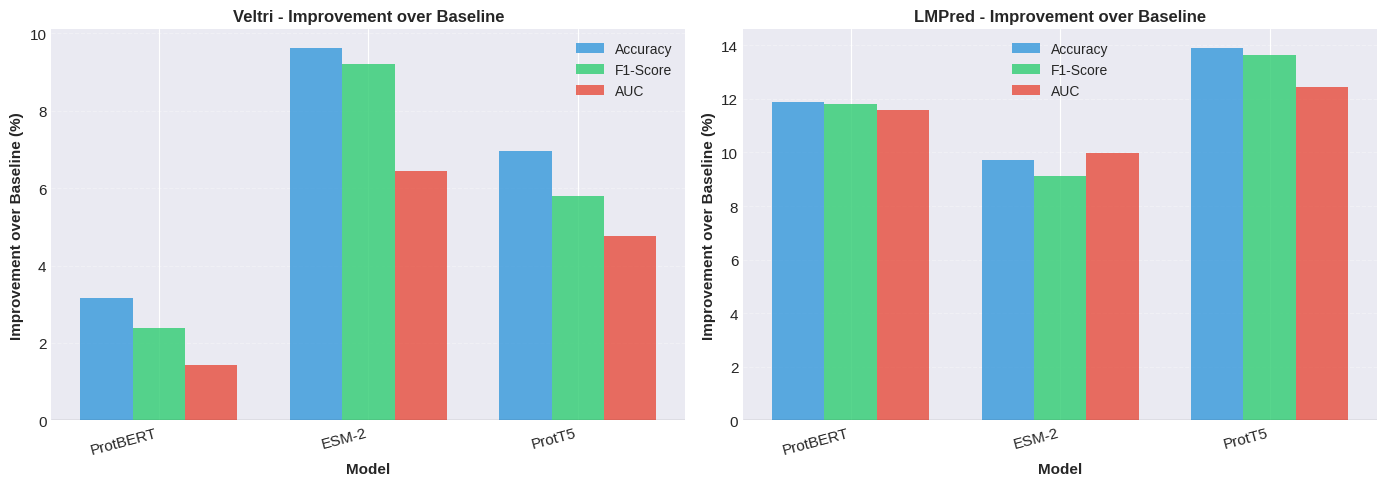

✓ Saved: improvement_over_baseline.png


In [9]:
# Visualize improvement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, dataset in enumerate(['Veltri', 'LMPred']):
    data = results[results['Dataset'] == dataset]
    baseline = data[data['Model'] == 'Baseline-LR (k=3)'].iloc[0]
    transformer_models = data[data['Model'] != 'Baseline-LR (k=3)']

    improvements = []
    model_names = []

    for _, row in transformer_models.iterrows():
        acc_imp = (row['Test_Accuracy'] - baseline['Test_Accuracy']) * 100
        f1_imp = (row['Test_F1'] - baseline['Test_F1']) * 100
        auc_imp = (row['Test_AUC'] - baseline['Test_AUC']) * 100

        improvements.append([acc_imp, f1_imp, auc_imp])
        model_names.append(row['Model'])

    improvements = np.array(improvements)

    x = np.arange(len(model_names))
    width = 0.25

    axes[idx].bar(x - width, improvements[:, 0], width, label='Accuracy', color='#3498db', alpha=0.8)
    axes[idx].bar(x, improvements[:, 1], width, label='F1-Score', color='#2ecc71', alpha=0.8)
    axes[idx].bar(x + width, improvements[:, 2], width, label='AUC', color='#e74c3c', alpha=0.8)

    axes[idx].set_xlabel('Model', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Improvement over Baseline (%)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{dataset} - Improvement over Baseline', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(model_names, rotation=15, ha='right')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.savefig('improvement_over_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: improvement_over_baseline.png")

## 7. Model Ranking Analysis

In [10]:
# Rank models by different metrics
print("=" * 80)
print("MODEL RANKINGS BY METRIC")
print("=" * 80)

metrics = ['Test_Accuracy', 'Test_F1', 'Test_AUC']
metric_names = ['Accuracy', 'F1-Score', 'AUC']

for dataset in ['Veltri', 'LMPred']:
    data = results[results['Dataset'] == dataset].copy()

    print(f"\n{dataset} Dataset:")
    print(f"{'Metric':<15} {'1st Place':<20} {'2nd Place':<20} {'3rd Place':<20}")
    print("-" * 80)

    for metric, name in zip(metrics, metric_names):
        sorted_data = data.sort_values(metric, ascending=False)
        top3 = sorted_data['Model'].head(3).tolist()

        print(f"{name:<15} {top3[0]:<20} {top3[1]:<20} {top3[2]:<20}")

print("\n" + "=" * 80)

MODEL RANKINGS BY METRIC

Veltri Dataset:
Metric          1st Place            2nd Place            3rd Place           
--------------------------------------------------------------------------------
Accuracy        ESM-2                ProtT5               ProtBERT            
F1-Score        ESM-2                ProtT5               ProtBERT            
AUC             ESM-2                ProtT5               ProtBERT            

LMPred Dataset:
Metric          1st Place            2nd Place            3rd Place           
--------------------------------------------------------------------------------
Accuracy        ProtT5               ProtBERT             ESM-2               
F1-Score        ProtT5               ProtBERT             ESM-2               
AUC             ProtT5               ProtBERT             ESM-2               



## 8. Cross-Dataset Performance

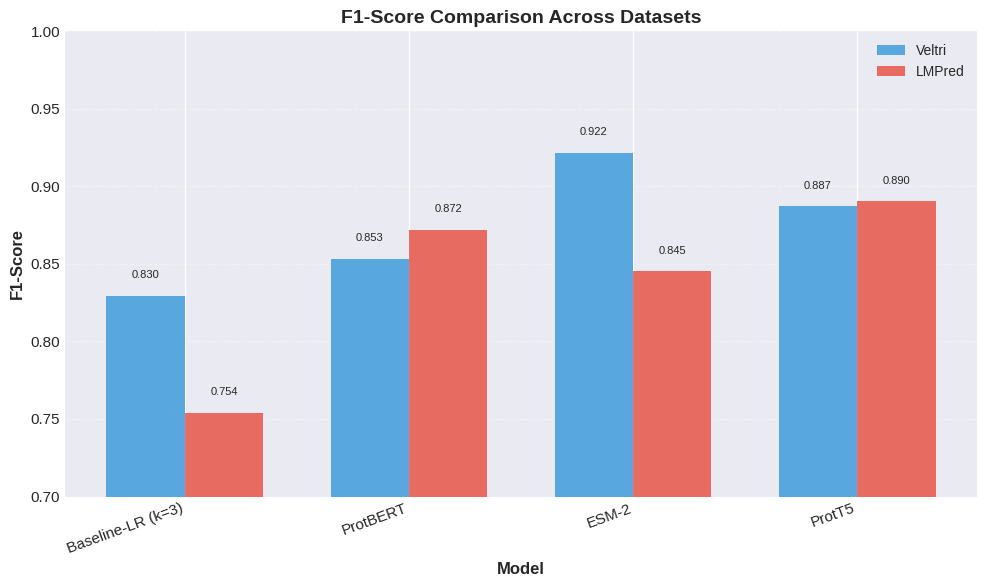

✓ Saved: cross_dataset_performance.png


In [11]:
# Compare performance across datasets
fig, ax = plt.subplots(figsize=(10, 6))

models = results['Model'].unique()
x = np.arange(len(models))
width = 0.35

veltri_f1 = [results[(results['Model'] == m) & (results['Dataset'] == 'Veltri')]['Test_F1'].values[0] for m in models]
lmpred_f1 = [results[(results['Model'] == m) & (results['Dataset'] == 'LMPred')]['Test_F1'].values[0] for m in models]

ax.bar(x - width/2, veltri_f1, width, label='Veltri', color='#3498db', alpha=0.8)
ax.bar(x + width/2, lmpred_f1, width, label='LMPred', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('F1-Score Comparison Across Datasets', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0.7, 1.0])

# Add value labels on bars
for i, (v, l) in enumerate(zip(veltri_f1, lmpred_f1)):
    ax.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width/2, l + 0.01, f'{l:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cross_dataset_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: cross_dataset_performance.png")